In [1]:
import pandas as pd
import numpy as np

In [32]:
df1 = pd.read_csv('earthquake_1995-2023.csv')
df2 = pd.read_csv('dataset2.csv')

First Dataset (nazwa):

In [7]:
print("Columns of first dataset:", df1.columns)

Columns of first dataset: Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='object')


- title: title name given to the earthquake
- magnitude: The magnitude of the earthquake
- date_time: date and time
- cdi: The maximum reported intensity for the event range
- mmi: The maximum estimated instrumental intensity for the event
- alert: The alert level - “green”, “yellow”, “orange”, and “red”
- tsunami: "1" for events in oceanic regions and "0" otherwise
- sig: A number describing how significant the event is. Larger numbers indicate a more significant event. This value is determined on a number of factors, including: magnitude, maximum MMI, felt reports, and estimated impact
- net: The ID of a data contributor. Identifies the network considered to be the preferred source of information for this event.
- nst: The total number of seismic stations used to determine earthquake location.
- dmin: Horizontal distance from the epicenter to the nearest station
- gap: The largest azimuthal gap between azimuthally adjacent stations (in degrees). In general, the smaller this number, the more reliable is the calculated horizontal position of the earthquake. Earthquake locations in which the azimuthal gap exceeds 180 degrees typically have large location and depth uncertainties
- magType: The method or algorithm used to calculate the preferred magnitude for the event
- depth: The depth where the earthquake begins to rupture
- latitude / longitude: coordinate system by means of which the position or location of any place on Earth's surface can be determined and described
- location: location within the country
- continent: continent of the earthquake hit country
- country: affected country

Data Reprezentation and characteristics:

In [13]:
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 

Distribution of data points:

array([[<AxesSubplot:title={'center':'longitude'}>]], dtype=object)

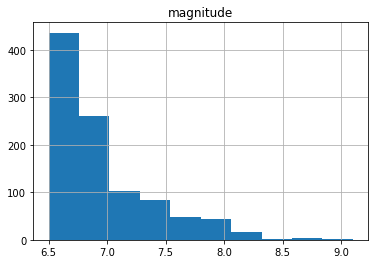

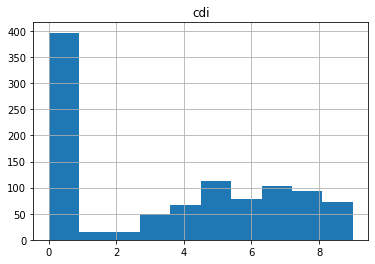

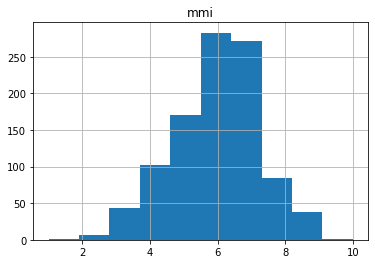

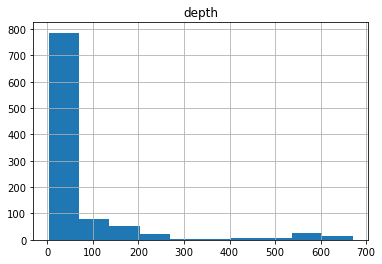

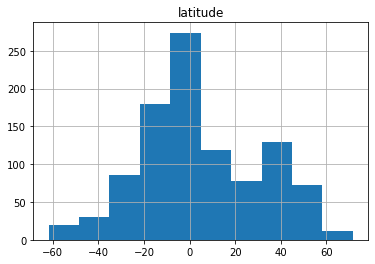

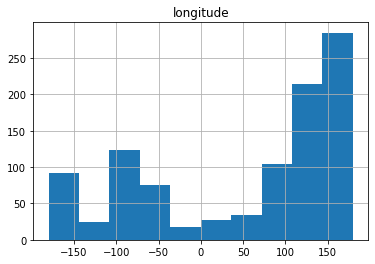

In [22]:
df1.hist(column="magnitude")
df1.hist(column="cdi")
df1.hist(column="mmi")
# df1.hist(column="sig") #not nessesery to much corelation
df1.hist(column="depth")
df1.hist(column="latitude")
df1.hist(column="longitude")


In [21]:
print(df1.depth)

0      192.955
1       69.727
2      171.371
3       32.571
4       21.000
        ...   
995     11.000
996     20.200
997     11.200
998     14.000
999     16.000
Name: depth, Length: 1000, dtype: float64


Correlation of first dataset:

In [11]:
df1.corr()

,magnitude,cdi,mmi,tsunami,sig,nst,dmin,gap,depth,latitude,longitude
magnitude,1.000000,0.163170,0.282275,-0.001213,0.512358,0.091427,-0.081518,-0.087029,0.017083,-0.017505,-0.010710
cdi,0.163170,1.000000,0.197458,0.292202,0.479911,-0.003857,0.140505,0.277689,-0.051331,0.065383,-0.132190
mmi,0.282275,0.197458,1.000000,-0.175441,0.398149,0.110260,-0.307331,-0.068503,-0.517002,0.180799,-0.019398
tsunami,-0.001213,0.292202,-0.175441,1.000000,0.024848,-0.426026,0.443179,0.236259,0.070705,-0.127002,-0.131340
sig,0.512358,0.479911,0.398149,0.024848,1.000000,0.016636,-0.051440,0.158853,-0.079263,0.177575,-0.164200
nst,0.091427,-0.003857,0.110260,-0.426026,0.016636,1.000000,-0.402445,0.003023,-0.103897,0.109991,0.156543
dmin,-0.081518,0.140505,-0.307331,0.443179,-0.051440,-0.402445,1.000000,0.091388,0.192698,-0.239791,-0.075595
gap,-0.087029,0.277689,-0.068503,0.236259,0.158853,0.003023,0.091388,1.000000,-0.062215,0.052368,-0.267812
depth,0.017083,-0.051331,-0.517002,0.070705,-0.079263,-0.103897,0.192698,-0.062215,1.000000,-0.101446,-0.030632
latitude,-0.017505,0.065383,0.180799,-0.127002,0.177575,0.109991,-0.239791,0.052368,-0.101446,1.000000,0.013604


The number varies from -1 to 1.

1 means that there is a 1 to 1 relationship (a perfect correlation), and for this data set, each time a value went up in the first column, the other one went up as well.

0.9 is also a good relationship, and if you increase one value, the other will probably increase as well.

-0.9 would be just as good relationship as 0.9, but if you increase one value, the other will probably go down.

0.2 means NOT a good relationship, meaning that if one value goes up does not mean that the other will.

***

Target variables:

- magnitude
- longitude
- latitude
- date

***

***

Second Dataset (nazwa):

In [33]:
print("Columns of second dataset:", df2.columns)

Columns of second dataset: Index(['Date', 'Time', 'Latitude', 'Longitude', 'Depth', 'Magnitude', 'Magt',
       'Nst', 'Gap', 'Clo', 'RMS', 'SRC', 'EventID'],
      dtype='object')


- Nst - number of stations used for solution (range: 0 to ...).
- Clo - distance of closest station to epicenter (range: 0 to ...).
- rms - root-mean-squared residual of solution (range: 0. to 1.).
- gap - azimuthal gap
- SRC - source

Data Reprezentation and characteristics:

In [34]:
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18030 entries, 0 to 18029
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       18030 non-null  object 
 1   Time       18030 non-null  object 
 2   Latitude   18030 non-null  float64
 3   Longitude  18030 non-null  float64
 4   Depth      18030 non-null  float64
 5   Magnitude  18030 non-null  float64
 6   Magt       18030 non-null  object 
 7   Nst        18030 non-null  int64  
 8   Gap        18030 non-null  int64  
 9   Clo        18030 non-null  int64  
 10  RMS        18030 non-null  float64
 11  SRC        18030 non-null  object 
 12  EventID    18030 non-null  int64  
dtypes: float64(5), int64(4), object(4)
memory usage: 1.8+ MB
None


Distribution of data points:

array([[<AxesSubplot:title={'center':'Longitude'}>]], dtype=object)

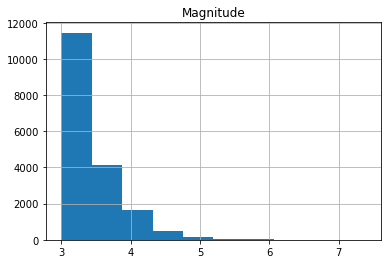

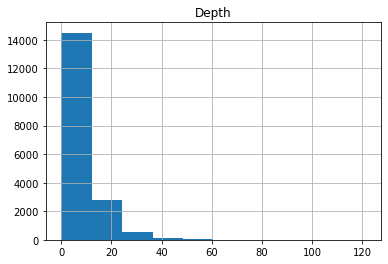

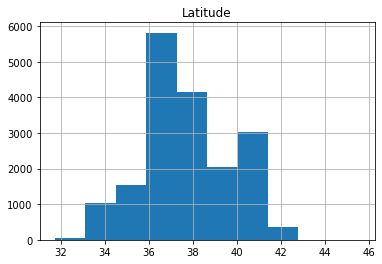

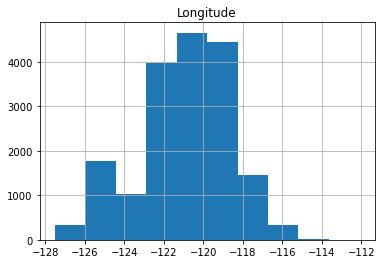

In [37]:
df2.hist(column="Magnitude")
df2.hist(column="Depth")
df2.hist(column="Latitude")
df2.hist(column="Longitude")

Correlation of second dataset:

In [38]:
df2.corr()

,Latitude,Longitude,Depth,Magnitude,Nst,Gap,Clo,RMS,EventID
Latitude,1.000000,-0.689649,0.178378,-0.049420,-0.023909,0.237796,0.219580,0.029009,0.047412
Longitude,-0.689649,1.000000,-0.191946,0.044320,-0.123702,-0.112306,-0.150490,-0.000630,0.003381
Depth,0.178378,-0.191946,1.000000,0.064242,-0.104166,0.200382,0.035952,-0.012568,-0.004466
Magnitude,-0.049420,0.044320,0.064242,1.000000,0.172483,0.074317,0.113880,0.027122,-0.013887
Nst,-0.023909,-0.123702,-0.104166,0.172483,1.000000,-0.360589,-0.048296,0.014463,0.205336
Gap,0.237796,-0.112306,0.200382,0.074317,-0.360589,1.000000,0.662613,0.063421,0.003018
Clo,0.219580,-0.150490,0.035952,0.113880,-0.048296,0.662613,1.000000,0.064213,0.122655
RMS,0.029009,-0.000630,-0.012568,0.027122,0.014463,0.063421,0.064213,1.000000,0.003955
EventID,0.047412,0.003381,-0.004466,-0.013887,0.205336,0.003018,0.122655,0.003955,1.000000
